# Data Exploration

In [ ]:
print("hello world")

## Imports and Connection

In [13]:
# Imports
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv

In [14]:
# Searches for .env
load_dotenv()

# Get database information
user = os.getenv("DB_USER")
password = os.getenv("DB_PASS")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_DATABASE")

# Initialize SQL engine
engine = create_engine(
    f"mysql+mysqlconnector://{user}:{password}@{host}:{port}/{database}",
    connect_args={"connection_timeout": 5}
)

def run(query):
    return pd.read_sql(query, con=engine)

try:
    result = run("SELECT 1 AS connected")
    print(f"Success {result.iloc[0,0]}")
except Exception as e:
    print(f"Connection failed.")

Success 1


## Database Information

### Show Tables

In [4]:
table_query = """
SHOW FULL TABLES
WHERE Table_type = 'BASE TABLE';
"""

tables = pd.read_sql(table_query, con=engine)
tables

,Tables_in_profitssql,Table_type
0,items,BASE TABLE
1,order_history_hdrs,BASE TABLE
2,order_history_lines,BASE TABLE
3,po_history_hdrs,BASE TABLE
4,po_history_lines,BASE TABLE
5,vmi_tags,BASE TABLE


### Show Views

In [ ]:
view_query = """
SHOW FULL TABLES
WHERE Table_type = 'VIEW';
"""

views = pd.read_sql(view_query, con=engine)
views

,Tables_in_profitssql,Table_type
0,items_clean,VIEW
1,order_history_hdrs_clean,VIEW
2,order_history_lines_clean,VIEW
3,po_history_hdrs_clean,VIEW
4,po_history_lines_clean,VIEW
5,vmitags_clean,VIEW
6,ytd_profit_per_class,VIEW


### Create Full CSVs

In [ ]:
# Convert tables to CSV

# for table in tables["Tables_in_profitssql"]:
#     q = f"Select * from `{table}`;"
#     globals()[f"{table}_df"] = run(q)
#     globals()[f"{table}_df"].to_csv(f"{table}.csv", index=False)

### Create Cleaned CSVs

In [ ]:
from pathlib import Path

output_folder = Path("../../data")
output_folder.mkdir(parents=True, exist_ok=True)

# for view in views["Tables_in_profitssql"]:
#     if view != 'vmitags_clean' or view != 'ytd_profit_per_class':
#         query = f"SELECT * FROM `{view}`"
#         run(query).to_csv(output_folder / f"{view}.csv", index=False)


# Show most recent time this cell was ran
print(f"Last run: {pd.Timestamp.now()}")

Last run: 2026-09-22 00:49:02.553435


### Descriptions

In [ ]:
# for table in tables["Tables_in_profitssql"]:
#     q = f"DESCRIBE `{table}`;"
#     display(run(q))a

### Dimensions

In [ ]:
catalog_query = """
SELECT TABLE_NAME AS name, TABLE_TYPE AS table_type
FROM information_schema.tables
WHERE table_schema = DATABASE()
ORDER BY table_name;
"""
catalog = run(catalog_query)

summary_rows = []
for _, entry in catalog.iterrows():
    name = entry["name"]
    table_type = entry["table_type"]
    column_count = run(
        f"SELECT COUNT(*) FROM information_schema.columns "
        f"WHERE table_schema = DATABASE() AND table_name = '{name}'"
    ).squeeze()
    row_count = run(f"SELECT COUNT(*) FROM `{name}`").squeeze()
    summary_rows.append(
        {"name": name, "table_type": table_type, "columns": column_count, "rows": row_count}
    )

table_summary = pd.DataFrame(summary_rows)
table_summary

,name,table_type,columns,rows
0,items,BASE TABLE,130,1213
1,items_clean,VIEW,27,1111
2,order_history_hdrs,BASE TABLE,117,17751
3,order_history_hdrs_clean,VIEW,37,17751
4,order_history_lines,BASE TABLE,49,248932
5,order_history_lines_clean,VIEW,25,128900
6,po_history_hdrs,BASE TABLE,61,28616
7,po_history_hdrs_clean,VIEW,27,28616
8,po_history_lines,BASE TABLE,51,416711
9,po_history_lines_clean,VIEW,25,116227


### Data Recency

In [ ]:
query = "select max(item_lsale) as 'Last Sale' from items"

lsale = pd.to_datetime(run(query).squeeze())
print(lsale.strftime("%Y-%m-%d"))
print(f"Days since: {(pd.Timestamp.now().normalize() - lsale).days}")

2026-09-16
Days since: 1


## External Market Data

[*********************100%***********************]  1 of 1 completed


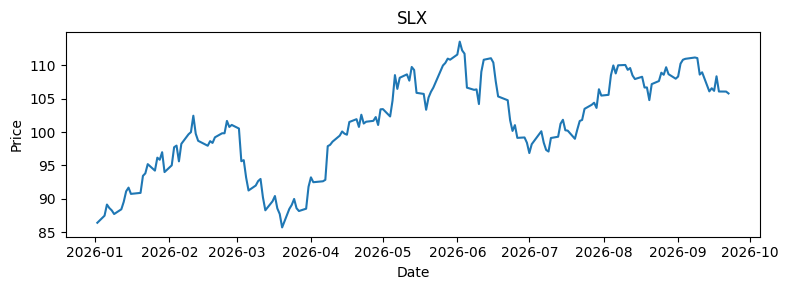

In [4]:
import yfinance as yf
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt

ticker = 'SLX'

df = yf.download(ticker, start='2026-01-01', end=dt.datetime.today(), auto_adjust=True)

df = df['Close'].squeeze().rename('Close').reset_index().round(2)
df['Date'] = pd.to_datetime(df['Date'])

plt.figure(figsize=(8,3))
plt.plot(df['Date'], df['Close'])
plt.xlabel('Date')
plt.ylabel('Price')
plt.title(f'{ticker}')
plt.tight_layout()
plt.show()

## Bid Shading
First Order Condition formula

--- First-Price Sealed-Bid FOC Simulation (5 Bidders) ---
Valuation (s): $ 9.18 | Optimal Bid (b): $ 7.35 | Shade Amount: $ 1.84
Valuation (s): $29.36 | Optimal Bid (b): $23.49 | Shade Amount: $ 5.87
Valuation (s): $49.55 | Optimal Bid (b): $39.64 | Shade Amount: $ 9.91
Valuation (s): $69.73 | Optimal Bid (b): $55.78 | Shade Amount: $13.95
Valuation (s): $89.91 | Optimal Bid (b): $71.93 | Shade Amount: $17.98


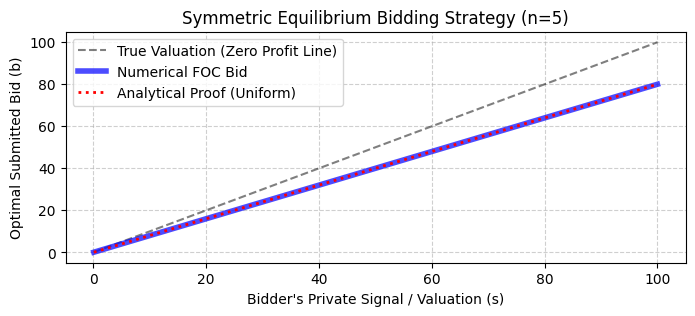

In [ ]:
import numpy as np
from scipy import integrate
import scipy.stats as stats
import matplotlib.pyplot as plt

def first_price_bid(s, n, cdf_func, s_min):
    """
    Calculates the symmetric equilibrium bid in a first-price sealed-bid auction 
    using the First Order Condition continuous formula.
    
    Parameters:
    s (float): Bidder's private valuation (signal)
    n (int): Total number of bidders
    cdf_func (callable): Cumulative Distribution Function of the valuations, F(s)
    s_min (float): The lowest possible valuation in the support (s lower bar)
    """
    if s <= s_min:
        return s_min
        
    # Denominator: F(s)^(n-1)
    F_s = cdf_func(s)
    if F_s == 0:
        return s
    denominator = F_s ** (n - 1)
    
    # Numerator Integral: integral from s_min to s of F(x)^(n-1) dx
    def integrand(x):
        return cdf_func(x) ** (n - 1)
        
    integral_val, _ = integrate.quad(integrand, s_min, s)
    
    # FOC Equilibrium Bid Formula
    b_s = s - (integral_val / denominator)
    return b_s

# --- Configuration ---
n_bidders = 5
s_min = 0
s_max = 100

# Define the environment's probability distribution (Uniform used here as baseline)
distribution = stats.uniform(loc=s_min, scale=s_max - s_min)

# Generate an array of possible simulated valuations
valuations = np.linspace(s_min + 0.1, s_max, 100)

# Calculate numerical bids using the FOC integration
numerical_bids = [first_price_bid(s, n_bidders, distribution.cdf, s_min) for s in valuations]

# For a Uniform distribution, the analytical known solution is exactly: b(s) = s * (n-1)/n
# We calculate this to prove the numerical integral logic is flawlessly matching theory
analytical_bids = valuations * ((n_bidders - 1) / n_bidders)

# --- Console Output ---
print(f"--- First-Price Sealed-Bid FOC Simulation ({n_bidders} Bidders) ---")
for val, bid in zip(valuations[9::20], numerical_bids[9::20]):
    print(f"Valuation (s): ${val:5.2f} | Optimal Bid (b): ${bid:5.2f} | Shade Amount: ${val-bid:5.2f}")

# --- Visualization ---
plt.figure(figsize=(8, 3))
plt.plot(valuations, valuations, 'k--', alpha=0.5, label="True Valuation (Zero Profit Line)")
plt.plot(valuations, numerical_bids, 'b-', linewidth=4, alpha=0.7, label="Numerical FOC Bid")
plt.plot(valuations, analytical_bids, 'r:', linewidth=2, label="Analytical Proof (Uniform)")

plt.title(f"Symmetric Equilibrium Bidding Strategy (n={n_bidders})")
plt.xlabel("Bidder's Private Signal / Valuation (s)")
plt.ylabel("Optimal Submitted Bid (b)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()